# Digit Classification by MLP in PyTorch

In this notebook, we will create a small a multilayer perceptron to perform image classification on MNIST.

___

In [42]:
# === SYSTEM INFORMATION CHECKER ===
# This script collects system details.

import platform
import psutil
import os
import socket
from datetime import datetime

def get_system_info():
    # OS Details
    os_name = platform.system()
    os_version = platform.version()
    os_release = platform.release()
    os_machine = platform.machine()
    
    # Python Version
    python_version = platform.python_version()
    
    # CPU Architecture and Count
    cpu_architecture = platform.architecture()[0]
    num_cores = psutil.cpu_count(logical=True)
    
    # Memory (RAM)
    memory_info = psutil.virtual_memory()
    total_ram = memory_info.total / (1024**3)  # GB
    available_ram = memory_info.available / (1024**3)  # GB
    
    # Disk Space (on the primary drive - usually C:)
    disk_usage = psutil.disk_usage('/')
    total_disk = disk_usage.total / (1024**3)
    free_disk = disk_usage.free / (1024**3)
    
    # Timestamp
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    print("="*60)
    print("SYSTEM INFORMATION")
    print("="*60)
    print(f"OS Type: {os_name}")
    print(f"OS Version: {os_version} ({os_release})")
    print(f"Machine Architecture: {os_machine} ({cpu_architecture})")
    print(f"Python Version: {python_version}")
    print(f"Number of CPU Cores (Logical): {num_cores}")
    print(f"RAM Total: {total_ram:.2f} GB | Available: {available_ram:.2f} GB")
    print(f"Disk Usage (Root): {total_disk:.2f} GB | Free: {free_disk:.2f} GB")
    print(f"Timestamp: {timestamp}")
    print("="*60)


# === Run this cell to collect system info ===
get_system_info()


SYSTEM INFORMATION
OS Type: Windows
OS Version: 10.0.26100 (10)
Machine Architecture: AMD64 (64bit)
Python Version: 3.11.4
Number of CPU Cores (Logical): 8
RAM Total: 15.70 GB | Available: 5.53 GB
Disk Usage (Root): 439.45 GB | Free: 302.31 GB
Timestamp: 2026-04-11 22:14:04


In [43]:
import torch
import torch.nn as nn

print("Torch version:", torch.__version__)

Torch version: 2.10.0+cpu


In [44]:
import matplotlib.pyplot as plt

In PyTorch, there are many predefined layer like Convolutions, RNN, Pooling, Linear, etc.

These functions are wrapped in **modules** and inherit from the **torch.nn.Module** base class.

When designing a custom model in PyTorch, you should follow this strategy and derive your class from **torch.nn.Module**.

For more information about PyTorch Modules see:
<!--NAVIGATION-->
## [Modules](App-PyTorch-Modules.ipynb)

___

## Simple network for image classification

### Let's create a Multi Layer Perceptron Network (MLP)

Implement a simple multilayer perceptron with one hidden layers and the following structure: (The figure is drawn using http://alexlenail.me/NN-SVG/index.html)
![MLP](figures/MLP_30_15_10.svg)

- Input-size: 64*64=784
- hidden layer: 75
- Output layer: num_classes=10

You will need some PyTorch NN modules - Find them in the [PyTorch doc](https://pytorch.org/docs/master/nn.html) (especially nn.Linear)!

In [45]:
from torch.nn import Parameter
import torch.nn.functional as F  # provides some helper functions like Relu's, Sigmoids, Tanh, etc.


class MyMultilayerPerceptron(nn.Module):
    def __init__(self, input_size, h_dim, num_classes):
        super(MyMultilayerPerceptron, self).__init__()
        
        self.input_size = input_size
        self.num_classes = num_classes
        
        self.linear_1 = nn.Linear(input_size, h_dim)
        self.linear_2 = nn.Linear(h_dim, num_classes)
        
    
    def forward(self, x):
        x = F.relu(self.linear_1(x))
        x = F.relu(self.linear_2(x))
        return F.softmax(x)

### Print your network's parameters

In [46]:
model = MyMultilayerPerceptron(784, 75, 10)
print(model)

MyMultilayerPerceptron(
  (linear_1): Linear(in_features=784, out_features=75, bias=True)
  (linear_2): Linear(in_features=75, out_features=10, bias=True)
)


### Feed an input to your network

In [47]:
x = torch.rand(1, 784)  # the first dimension is reserved for the 'batch_size'
out = model(x)  # equivalent to model.forward(x)
out[0, :]

C:\Users\Tara\AppData\Local\Temp\ipykernel_19296\2796298509.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


tensor([0.0900, 0.0900, 0.0900, 0.1082, 0.1117, 0.0900, 0.0900, 0.1073, 0.0932,
        0.1294], grad_fn=<SelectBackward0>)

___

## Training a model

Most of the functions to train a model follow a similar pattern in PyTorch.
In most of the cases in consists of the following steps:
- Loop over data (in batches)
- Forward pass
- Zero gradients!
- Backward pass
- Parameter update (Optimizer)

In [48]:
def train(model, num_epochs, data_loader, device):
    model = model.to(device)
    
    # Define the Loss function and Optimizer that you want to use
    criterion = nn.CrossEntropyLoss()  
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # NOTE: model.parameters()
    
    # Outter training loop
    for epoch in range(num_epochs):
        # Inner training loop
        cum_loss = 0
        for (inputs, labels) in data_loader:
            # Prepare inputs and labels for processing by the model (e.g. reshape, move to device, ...)
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # original shape is [batch_size, 28, 28] because it's an image of size 28x28
            inputs = inputs.view(-1, 28*28)

            # Do Forward -> Loss Computation -> Backward -> Optimization
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            cum_loss += loss.item()
        print("Epoch %d, Loss=%.4f" % (epoch+1, cum_loss/len(train_loader)))

Note:
- we can use the `.to` function on the model directly. Indeed, since PyTorch knows all the model parameters, it can put all the parameters on the correct device.
- we use `model.parameters()` to get all the parameters of the model and we can instantiate an optimizer that will optimize these parameters `torch.optim.SGD(model.parameters())`.
- to apply the forward function of the module, we write `model(input)`. In most cases, `model.forward(inputs)` would also work, but there is a slight difference : PyTorch allows you to register hook functions for a model that are automatically called when you do a forward pass on your model. Using `model(input)` will call these hooks and then call the forward function, while using `model.forward(inputs)` will just silently ignore them.

Do you feel the power of Modules ?

## Loss functions

PyTorch comes with a lot of predefined loss functions :
- L1Loss
- MSELoss
- CrossEntropyLoss
- NLLLoss
- PoissonNLLLoss
- KLDivLoss
- BCELoss
- MarginRankingLoss
- HingeEmbeddingLoss
- MultiLabelMarginLoss
- CosineEmbeddingLoss
- TripletMarginLoss
- ...

Check out the [PyTorch Documentation](https://pytorch.org/docs/master/nn.html#loss-functions).

___

## Let's train our model on the MNIST digit classification task


![MNIST](figures/mnist.jpeg)

First, we have to load the training and test images. MNIST is a widely used dataset, therefore the torchvision package provides simple functionalities to load images from it.

In [49]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

batch_size = 64

# MNIST Dataset (Images and Labels)
train_dataset = datasets.MNIST(root='../data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='../data', train=False, transform=transforms.ToTensor())

# Dataset Loader (Input Batcher)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In PyTorch, `Dataset` and `Dataloaders` are classes that can help to quickly define how to access and iterate over your data. This is specially interesting when your data is distributed over several files (for instance, if you have several images in some directory structure).

In [50]:
# Number of parameters, without bias
784*75+75*10

59550

### Call the actual training function

In [51]:
%%time
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyMultilayerPerceptron(input_size=784, h_dim=75, num_classes=10)
num_epochs = 25

train(model, num_epochs, train_loader, device)

C:\Users\Tara\AppData\Local\Temp\ipykernel_19296\2796298509.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Epoch 1, Loss=1.8248
Epoch 2, Loss=1.7650
Epoch 3, Loss=1.7531
Epoch 4, Loss=1.7458
Epoch 5, Loss=1.7408
Epoch 6, Loss=1.7370
Epoch 7, Loss=1.7338
Epoch 8, Loss=1.7315
Epoch 9, Loss=1.7296
Epoch 10, Loss=1.7283
Epoch 11, Loss=1.7268
Epoch 12, Loss=1.7257
Epoch 13, Loss=1.7247
Epoch 14, Loss=1.7241
Epoch 15, Loss=1.7231
Epoch 16, Loss=1.7222
Epoch 17, Loss=1.7215
Epoch 18, Loss=1.7210
Epoch 19, Loss=1.7208
Epoch 20, Loss=1.7203
Epoch 21, Loss=1.7201
Epoch 22, Loss=1.7194
Epoch 23, Loss=1.7190
Epoch 24, Loss=1.7190
Epoch 25, Loss=1.7187
CPU times: total: 32min 29s
Wall time: 8min 16s


### How can we now assess the model's performance?

This function loops over another `data_loader` (usually containing test/validation data) and computes the model's accuracy on it.

In [52]:
def accuracy(model, data_loader, device):
    with torch.no_grad(): # during model evaluation, we don't need the autograd mechanism (speeds things up)
        correct = 0
        total = 0
        for inputs, labels in data_loader:
            inputs = inputs.to(device)     
            inputs = inputs.view(-1, 28*28)
            
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            correct += (predicted.cpu() == labels).sum().item()
            total += labels.size(0)
            
    acc = correct / total
    return acc

In [53]:
accuracy(model, test_loader, device)  # look at: accuracy(model, train_loader, device)

C:\Users\Tara\AppData\Local\Temp\ipykernel_19296\2796298509.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


0.7797

____

## How can we now store our trained model?

In [54]:
# torch.save(model, "my_model.pt")

In [55]:
# my_model_loaded = torch.load("my_model.pt")

In [56]:
# model.linear_3.bias, my_model_loaded.linear_3.bias

____

C:\Users\Tara\AppData\Local\Temp\ipykernel_19296\2796298509.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


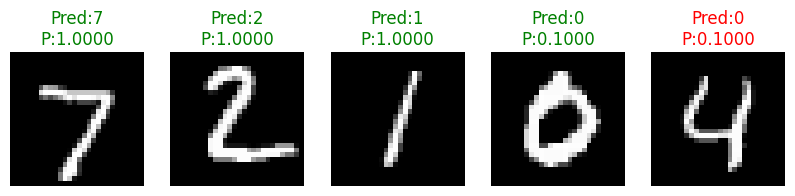

In [57]:

model.eval()

examples = iter(test_loader)
images, labels = next(examples)

plt.figure(figsize=(10,2))

for i in range(5):
    
    img = images[i].to(device)
    label = labels[i].item()
    img_input = img.view(-1, 28*28)

    output = model(img_input)
    prob, pred = torch.max(output, 1)

    pred = pred.item()
    prob = prob.item()

    color = "green"
    if pred != label:
        color = "red"

    plt.subplot(1,5,i+1)
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.title(f"Pred:{pred}\nP:{prob:.4f}", color=color)
    plt.axis("off")

plt.show()


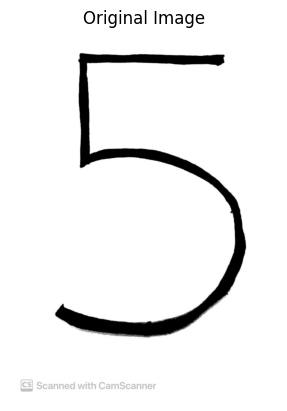

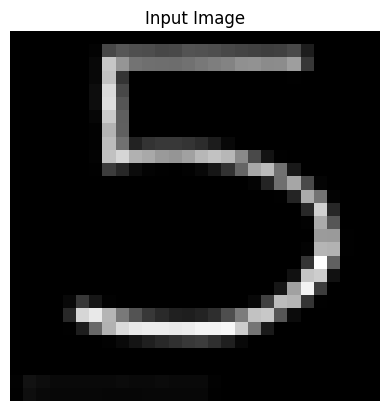

Predicted Digit: 5


C:\Users\Tara\AppData\Local\Temp\ipykernel_19296\2796298509.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


In [59]:
from PIL import Image
import torchvision.transforms as transforms

model.eval()
img_original = Image.open("digit.jpeg")
plt.imshow(img_original, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

img = Image.open("digit.jpeg").convert("L")   

transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

img_tensor = transform(img)

img_tensor = 1 - img_tensor

plt.imshow(img_tensor.squeeze(), cmap="gray")
plt.title("Input Image")
plt.axis("off")
plt.show()

img_input = img_tensor.view(1, 28*28).to(device)

output = model(img_input)
_, pred = torch.max(output, 1)

print("Predicted Digit:", pred.item())